O objetivo deste projeto é prever falhas operacionais e quebras mecânicas em equipamentos industriais monitorados por sensores antes que ocorram, evitando paradas não planejadas na linha de produção.
Variável Alvo Binária:

falha_maquina = 1: Ocorrência de falha/avaria no equipamento.
falha_maquina = 0: Funcionamento operacional normal.
2. Estratégia de Ciência de Dados
Tratamento de Desbalanceamento: Como as falhas representam um evento raro (~3,4% dos registros), aplicaremos a técnica SMOTE no conjunto de treino para evitar o viés do modelo para a classe majoritária.
Engenharia de Atributos: Criação de variáveis físicas derivadas (ex.: gradiente térmico delta_temp_k e relação de potência mecânica potencia_kW).
Métrica de Sucesso: Foco primário no Recall (Sensibilidade) e F1-Score, garantindo a minimização de falsos negativos (quebras não detectadas possuem custo financeiro significativamente maior do que alarmes falsos).

FASE I- analise exploratória (EDA) para conhecer os dados

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns

import pandas as pd

df = pd.read_csv("/home/codespace/.vscode-remote/data/agentSessionData/dc7c4210-5dd3-46a2-96ff-28f74d1914b7/attachments/ebb7591d-ce49-468b-b45a-07d9fa3423a1/manutencao_preditiva.csv")
df.head()

,udi,id_produto,tipo,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina,falha_twf,falha_hdf,falha_pwf,falha_osf,falha_rnf
0,1,M14860,M,298.1,308.6,1551.0,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408.0,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498.0,49.4,5,0,0,0,0,0,0
3,4,L47183,L,NaN,NaN,NaN,NaN,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408.0,40.0,9,0,0,0,0,0,0


In [2]:
df.shape # (linhas, colunas)
df.info() # tipo de cada coluna e quantos valores preenchidos
df.describe() # média, mínimo, máximo e quartis de cada coluna numérica
df.columns # nomes exatos: copie para a tabela de preenchimento

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   udi                      10000 non-null  int64  
 1   id_produto               10000 non-null  str    
 2   tipo                     10000 non-null  str    
 3   temperatura_ar_k         9500 non-null   float64
 4   temperatura_processo_k   9500 non-null   float64
 5   velocidade_rotacao_rpm   9500 non-null   float64
 6   torque_nm                9500 non-null   float64
 7   desgaste_ferramenta_min  10000 non-null  int64  
 8   falha_maquina            10000 non-null  int64  
 9   falha_twf                10000 non-null  int64  
 10  falha_hdf                10000 non-null  int64  
 11  falha_pwf                10000 non-null  int64  
 12  falha_osf                10000 non-null  int64  
 13  falha_rnf                10000 non-null  int64  
dtypes: float64(4), int64(8), str(2)
me

Index(['udi', 'id_produto', 'tipo', 'temperatura_ar_k',
       'temperatura_processo_k', 'velocidade_rotacao_rpm', 'torque_nm',
       'desgaste_ferramenta_min', 'falha_maquina', 'falha_twf', 'falha_hdf',
       'falha_pwf', 'falha_osf', 'falha_rnf'],
      dtype='str')

Histograma das variaveis

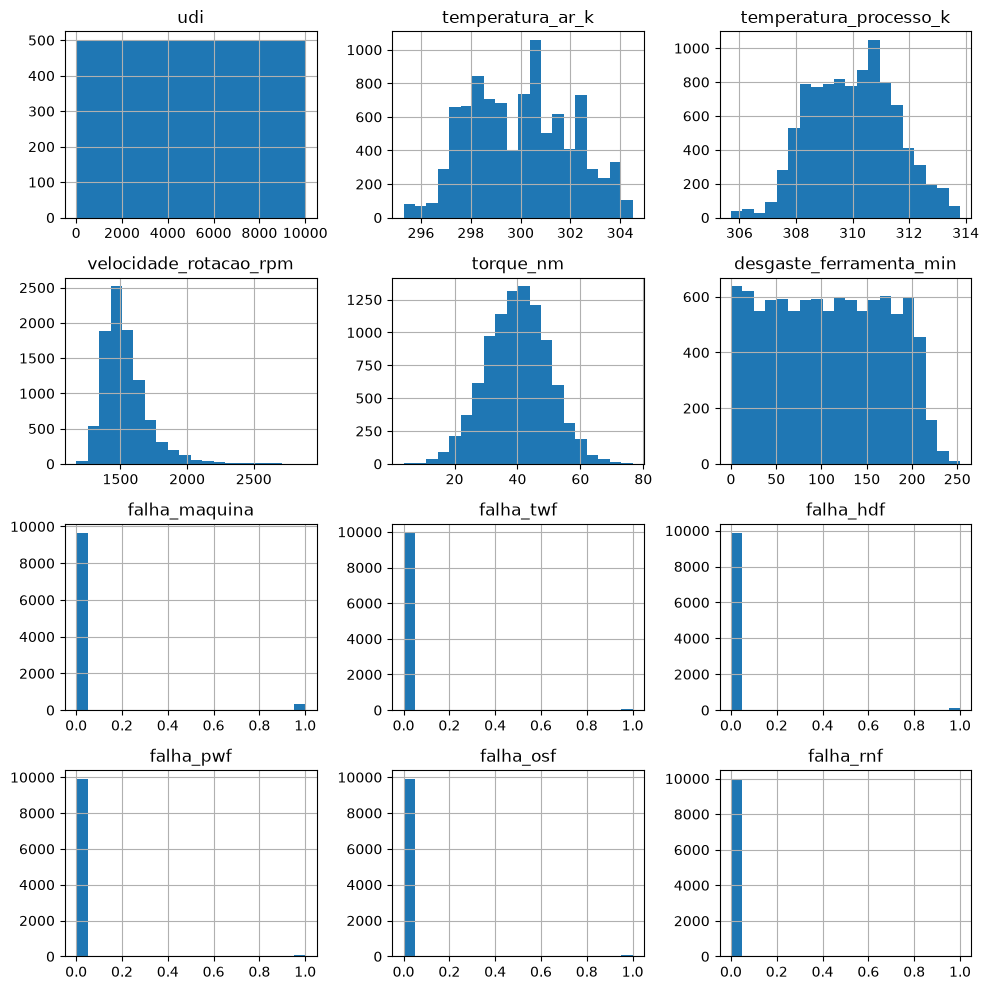

In [3]:
df.hist(figsize=(10, 10), bins=20)
plt.tight_layout()
plt.show()

Barras das colunas

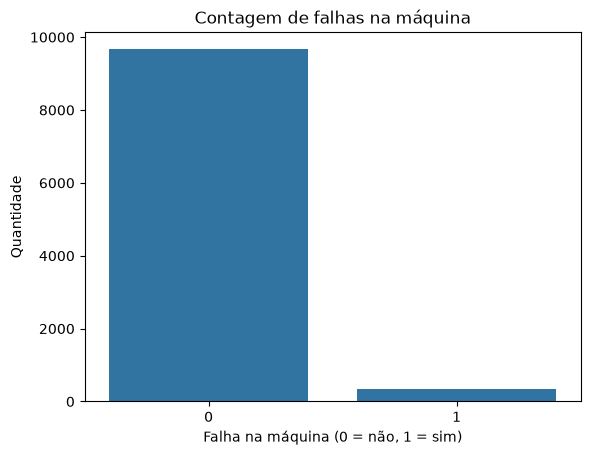

In [4]:
sns.countplot(data=df, x="falha_maquina")
plt.title("Contagem de falhas na máquina")
plt.xlabel("Falha na máquina (0 = não, 1 = sim)")
plt.ylabel("Quantidade")
plt.show()

In [5]:
df["falha_maquina"].value_counts(normalize=True) * 100

falha_maquina
0    96.61
1     3.39
Name: proportion, dtype: float64

Mapa de calor de correlação

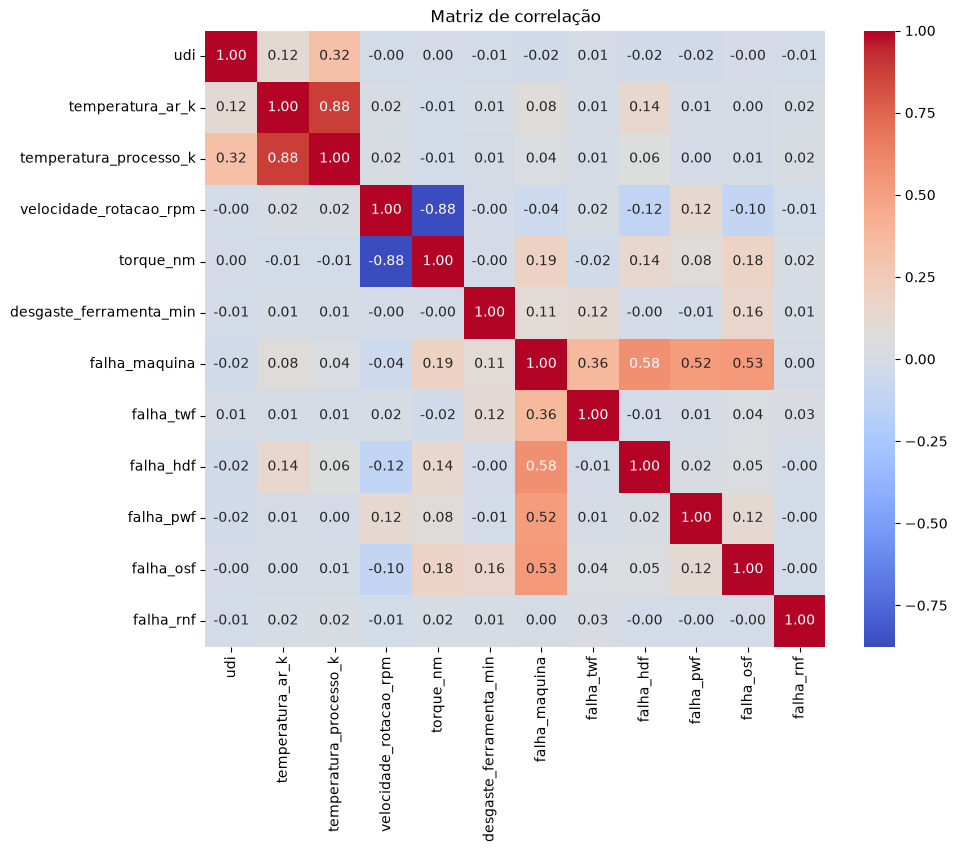

In [6]:
# numeric_only=True ignora colunas de texto (sem isso, dá erro se houver alguma)
correlacao = df.corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(correlacao, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlação")
plt.show()

ANALISE DA FASE:
A base tem 10.000 linhas e 14 colunas, sendo 12 colunas numéricas e 2 de texto 
Seguem os padrões numéricos (12): udi,n temperatura_ar_k, temperatura_processo_k, velocidade_rotacao_rpm, torque_nm, desgaste_ferramenta_min, falha_maquina, falha_twf, falha_hdf, falha_pwf, falha_osf e falha_rnf.
E no Texto (2): id_produto e tipo.
S base udi é numérica, porém funciona como identificador, já as colunas falha_* são números que representam categorias binárias (0 ou 1)
A coluna falha_maquina mostra 3,39% de registros com falha e 96,61% sem falha — cerca de 339 casos de falha em 10.000 registros. Isso significa que as falhas são raras e a base está desbalanceada.
Na coluna falha_maquina, 3,39% das linhas são 1 — aproximadamente 339 de 10.000. As outras 96,61% são 0, então há um forte desbalanceamento entre as classes.

Isso necessita do uso do SMOTE em dados de treino, depois de separar treino e teste, para evitar que exemplos sintéticos contaminem a avaliação. 
Entre as variáveis de processo, as maiores correlações com falha_maquina parecem ser torque_nm — correlação positiva mais forte: torque maior tende a aparecer mais associado a falhas.
Há desgaste_ferramenta_min — correlação positiva: mais desgaste também tende a estar associado a falhas.
velocidade_rotacao_rpm — correlação negativa, mas bem mais fraca; isoladamente, é um sinal menos claro.
Isso faz sentido na fábrica diante do esforço elevado que pode aumentar o torque, e uma ferramenta mais desgastada pode elevar o risco de falha. Mas correlação não prova causa e efeito; vale analisar essas variáveis junto com o contexto operacional.

Nesse momento  não há como afirmar falha_twf, falha_hdf, falha_pwf, falha_osf e falha_rnf como preditoras. São tipos de falha e podem revelar diretamente o resultado que se quer prever, causando vazamento de informação no modelo.
Temperaturas de aproximadamente 295–314 K, rotação mínima de 1.168 rpm e torque mínimo de 3,8 Nm parecem possíveis.

O máximo de 2.886 rpm em velocidade_rotacao_rpm chama atenção por ser alto em relação à maior concentração do histograma, mas não é impossível por si só — vale conferir esse registro e o limite operacional da máquina. O máximo de 253 min em desgaste_ferramenta_min também merece atenção, mas pode ser válido dependendo do processo.
parecem valores extremos para investigar, não erros confirmados. As colunas udi e falha_* não são medidas físicas; seus mínimos e máximos são esperados (identificador e indicadores 0/1).

In [7]:
import pandas as pd

df = pd.read_csv(
    '/workspaces/DESENVOLVIMENTO-DE-IA-PARA-ANALISE-PREDITIVA/preditor-falhas-industria/data/"manutencao_preditiva.csv"'
)

df.duplicated().sum()

np.int64(0)

In [8]:
df.duplicated().sum()
# quantas linhas são cópia de outra

np.int64(0)

In [9]:
df = df.drop_duplicates()
df.shape
# conferir: o número de linhas diminuiu?

(10000, 14)

In [10]:
df.isnull().sum()
# quantos vazios em cada coluna

udi                          0
id_produto                   0
tipo                         0
temperatura_ar_k           500
temperatura_processo_k     500
velocidade_rotacao_rpm     500
torque_nm                  500
desgaste_ferramenta_min      0
falha_maquina                0
falha_twf                    0
falha_hdf                    0
falha_pwf                    0
falha_osf                    0
falha_rnf                    0
dtype: int64

In [11]:
colunas = [
    "temperatura_ar_k",
    "temperatura_processo_k",
    "velocidade_rotacao_rpm",
    "torque_nm",
    "desgaste_ferramenta_min"
]

df[colunas].skew().sort_values()

torque_nm                 -0.007881
temperatura_processo_k     0.015643
desgaste_ferramenta_min    0.027292
temperatura_ar_k           0.114931
velocidade_rotacao_rpm     1.994640
dtype: float64

O resultado mostra o valor de assimetria de cada variável: **perto de 0** indica distribuição aproximadamente simétrica; **acima de 1** indica assimetria à direita acentuada; **abaixo de -1**, à esquerda. 

In [12]:
for coluna in [
    "temperatura_ar_k",
    "temperatura_processo_k",
    "velocidade_rotacao_rpm",
    "torque_nm"
]:
    df[coluna] = df[coluna].fillna(df[coluna].median())

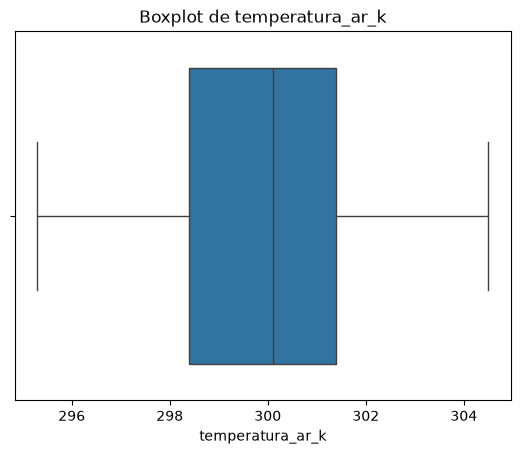

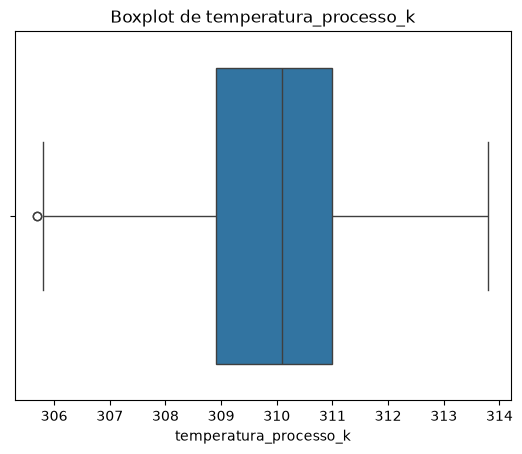

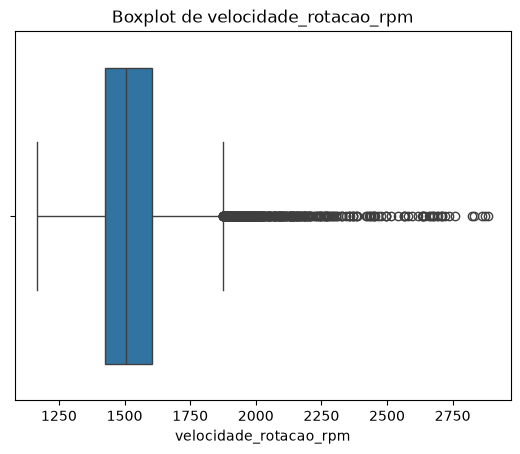

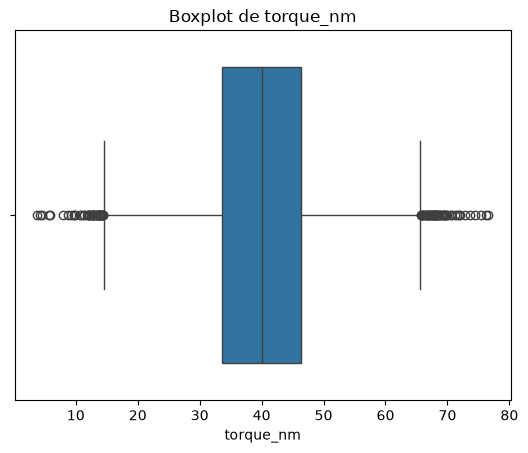

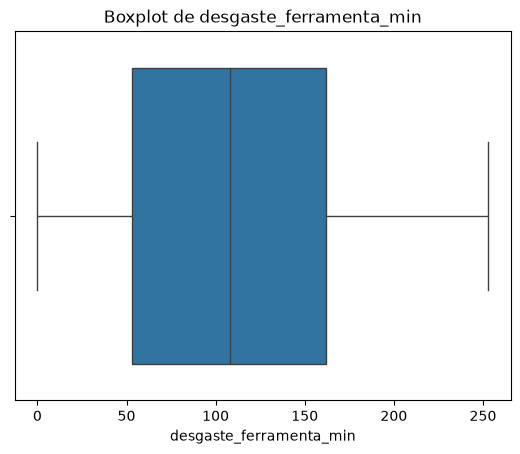

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

colunas = [
    "temperatura_ar_k",
    "temperatura_processo_k",
    "velocidade_rotacao_rpm",
    "torque_nm",
    "desgaste_ferramenta_min"
]

for coluna in colunas:
    sns.boxplot(data=df, x=coluna)
    plt.title(f"Boxplot de {coluna}")
    plt.show()

A velocidade_rotacao_rpm tem uma cauda à direita, vamos filtrar valores acima do limite superior pelo critério do intervalo interquartil (IQR), em vez de escolher um valor arbitrário.

In [14]:
coluna = "velocidade_rotacao_rpm"

q1 = df[coluna].quantile(0.25)
q3 = df[coluna].quantile(0.75)
limite_superior = q3 + 1.5 * (q3 - q1)

df = df[df[coluna] <= limite_superior]

In [15]:
df[[
    "temperatura_ar_k",
    "temperatura_processo_k",
    "velocidade_rotacao_rpm",
    "torque_nm"
]].isna().sum()

temperatura_ar_k          0
temperatura_processo_k    0
velocidade_rotacao_rpm    0
torque_nm                 0
dtype: int64

In [16]:
duplicados = df.duplicated().sum()
print("Duplicados:", duplicados)
print("Linhas após remover duplicados:", len(df.drop_duplicates()))

Duplicados: 0
Linhas após remover duplicados: 9535


# Final da fase (comentário)
#Tratamento de valores ausentes e outliers:
os valores ausentes das variáveis numéricas foram preenchidos com a mediana de cada coluna, por ser menos sensível a valores extremos do que a média. 
Não foram removidas linhas com `dropna()` nem excluídos valores identificados como outliers, pois podem representar condições reais de operação. 
Essa escolha preserva os registros; valores extremos devem ser removidos apenas se houver evidência de erro ou confirmação da engenharia.

FASE 3: Engenharia de Atributos

In [17]:
import pandas as pd

df = pd.read_csv(
    '/workspaces/DESENVOLVIMENTO-DE-IA-PARA-ANALISE-PREDITIVA/preditor-falhas-industria/data/"manutencao_preditiva.csv"'
)

df["potencia"] = df["velocidade_rotacao_rpm"] * df["torque_nm"] * (2 * 3.141592653589793 / 60) / 1000
df.head()

,udi,id_produto,tipo,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina,falha_twf,falha_hdf,falha_pwf,falha_osf,falha_rnf,potencia
0,1,M14860,M,298.1,308.6,1551.0,42.8,0,0,0,0,0,0,0,6.951591
1,2,L47181,L,298.2,308.7,1408.0,46.3,3,0,0,0,0,0,0,6.826723
2,3,L47182,L,298.1,308.5,1498.0,49.4,5,0,0,0,0,0,0,7.749388
3,4,L47183,L,NaN,NaN,NaN,NaN,7,0,0,0,0,0,0,NaN
4,5,L47184,L,298.2,308.7,1408.0,40.0,9,0,0,0,0,0,0,5.897817


In [18]:
df["potencia"].isnull().sum()
# tem que dar 0

np.int64(500)

In [19]:
df = df.dropna(
    subset=["velocidade_rotacao_rpm", "torque_nm"]
).copy()

df["potencia"] = (
    df["velocidade_rotacao_rpm"]
    * df["torque_nm"]
    * (2 * 3.141592653589793 / 60)
    / 1000
)

df["potencia"].isnull().sum()  # deve retornar 0

np.int64(0)

In [20]:
df.corr(numeric_only=True)

,udi,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina,falha_twf,falha_hdf,falha_pwf,falha_osf,falha_rnf,potencia
udi,1.000000,0.115592,0.321820,-0.004582,0.002292,-0.011845,-0.021734,0.008692,-0.021989,-0.020125,-0.003501,-0.006128,0.003413
temperatura_ar_k,0.115592,1.000000,0.876601,0.022915,-0.013598,0.011470,0.083090,0.010947,0.137952,0.005887,0.003856,0.018197,-0.010988
temperatura_processo_k,0.321820,0.876601,1.000000,0.019094,-0.013585,0.009928,0.037497,0.007646,0.056591,0.000304,0.006345,0.022958,-0.010259
velocidade_rotacao_rpm,-0.004582,0.022915,0.019094,1.000000,-0.875414,-0.000649,-0.040791,0.016043,-0.120554,0.124817,-0.104819,-0.013471,-0.806752
torque_nm,0.002292,-0.013598,-0.013585,-0.875414,1.000000,-0.002557,0.188905,-0.021020,0.141473,0.082548,0.184582,0.016570,0.978863
desgaste_ferramenta_min,-0.011845,0.011470,0.009928,-0.000649,-0.002557,1.000000,0.107091,0.113901,0.000555,-0.009175,0.157935,0.011538,-0.002740
falha_maquina,-0.021734,0.083090,0.037497,-0.040791,0.188905,0.107091,1.000000,0.355771,0.575180,0.525043,0.536573,0.004635,0.173745
falha_twf,0.008692,0.010947,0.007646,0.016043,-0.021020,0.113901,0.355771,1.000000,-0.007179,0.009736,0.025195,0.032531,-0.022201
falha_hdf,-0.021989,0.137952,0.056591,-0.120554,0.141473,0.000555,0.575180,-0.007179,1.000000,0.019848,0.048775,-0.004823,0.115563
falha_pwf,-0.020125,0.005887,0.000304,0.124817,0.082548,-0.009175,0.525043,0.009736,0.019848,1.000000,0.120454,-0.004402,0.086962


Analise da Fase 3:
a potência em watts de verdade é rpm × torque × 2π / 60. Como multiplicar por um número fixo não muda a correlação nem o modelo, rpm × torque já basta para o trabalho.
Girar rápido enquanto aplica muito torque significa maior potência e pode indicar maior carga e esforço mecânico. 
Isso pode aumentar aquecimento e desgaste, elevando o risco de falha.
Mas potência, sozinha, não prova que haverá falha. A máquina pode estar projetada para essa carga; por isso, a potência deve ser analisada junto com outras variáveis, como temperatura, desgaste e histórico de falhas.

# Fase 4: Divisão Treino/Teste e Balanceamento

In [21]:
df = pd.get_dummies(df, columns=["tipo"], dtype=int)
df.head()

,udi,id_produto,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina,falha_twf,falha_hdf,falha_pwf,falha_osf,falha_rnf,potencia,tipo_H,tipo_L,tipo_M
0,1,M14860,298.1,308.6,1551.0,42.8,0,0,0,0,0,0,0,6.951591,0,0,1
1,2,L47181,298.2,308.7,1408.0,46.3,3,0,0,0,0,0,0,6.826723,0,1,0
2,3,L47182,298.1,308.5,1498.0,49.4,5,0,0,0,0,0,0,7.749388,0,1,0
4,5,L47184,298.2,308.7,1408.0,40.0,9,0,0,0,0,0,0,5.897817,0,1,0
5,6,M14865,298.1,308.6,1425.0,41.9,11,0,0,0,0,0,0,6.252555,0,0,1


In [22]:
# X = variáveis de entrada; y = falha que queremos prever
X = df.drop(columns=[
    "falha_maquina",
    "udi",
    "id_produto",
    "falha_twf",
    "falha_hdf",
    "falha_pwf",
    "falha_osf",
    "falha_rnf",
])

y = df["falha_maquina"]

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,  # 20% para teste
    stratify=y,    # preserva a proporção de falhas
    random_state=42)


In [24]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_bal, y_train_bal = smote.fit_resample(
    X_train,
    y_train
)

y_train_bal.value_counts()

falha_maquina
0    7342
1    7342
Name: count, dtype: int64

# Analise da Fase 4
# o esperado é 7.600 linhas no treino e 1.900 no teste.
 # stratify=y manteve aproximadamente a mesma proporção de exemplos com e sem falha nos conjuntos de treino e teste. 
 # As porcentagens devem ser muito próximas entre treino e teste. 
 # Pode haver uma pequena diferença por arredondamento. 
 # y_train_bal não serve para essa conferência, pois o SMOTE balanceou suas classes.stratify=y preservou aproximadamente a mesma proporção de registros com falha (1) e sem falha (0) no treino e no teste.
 # Ele não balanceia as classes; apenas mantém a distribuição semelhante à original.
 # Pelo resultado do SMOTE, 7.342 = 0 e 7.342 = 1. 
 # O treino tinha 7.600 linhas, antes eram 7.342 =0 e 258 = 1
  # tamanho mostrado corresponde ao treino usado no SMOTE.

# Fase 5 Escalonamento (StandardScaler)

In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Aprende média e desvio no treino balanceado e transforma
X_train_knn = scaler.fit_transform(X_train_bal)

# Usa os parâmetros aprendidos no treino para transformar o teste
X_test_knn = scaler.transform(X_test)

In [26]:
X_train_knn = scaler.fit_transform(X_train_bal)
X_test_knn = scaler.transform(X_test)

In [27]:
X_train_knn.mean(axis=0).round(2)  # aproximadamente tudo 0
X_train_knn.std(axis=0).round(2)   # aproximadamente tudo 1

array([1., 1., 1., 1., 1., 1., 1., 1., 1.])

# Analise da Fase 6
# O KNN decide pela distância entre os exemplos. 
# Se uma variável tem valores muito maiores — por exemplo, rotação na casa dos milhares e temperatura na casa das centenas — ela pode dominar o cálculo da distância.
# O StandardScaler coloca as variáveis numa escala comparável, para que nenhuma pese mais apenas por ter números maiores.
# A Árvore de Decisão não depende de distâncias entre linhas.
# Ela escolhe pontos de corte em cada variável — por exemplo, temperatura < 300 — e esses cortes continuam equivalentes se a variável for reescalada. 
# Por isso, em geral, o StandardScaler não é necessário para árvores.
# Fazemos o fit só no treino para evitar vazamento de dados. 
# O fit calcula estatísticas, como média e desvio padrão; se usasse também o teste, o processo de treino teria informação sobre os dados reservados para avaliar o modelo.
#  Depois, aplicamos ao teste o mesmo padrão aprendido no treino com transform.

# Fase 6 ajuste de parâmetros e overfitting

In [28]:
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

K = 5
scaler = StandardScaler()
X_train_knn = scaler.fit_transform(X_train_bal)
X_test_knn = scaler.transform(X_test)

modelo_knn = KNeighborsClassifier(n_neighbors=K)
modelo_knn.fit(X_train_knn, y_train_bal)

acc_treino = accuracy_score(
    y_train_bal,
    modelo_knn.predict(X_train_knn)
)
acc_teste = accuracy_score(
    y_test,
    modelo_knn.predict(X_test_knn)
)

print("K =", K, "| treino:", acc_treino, "| teste:", acc_teste)


K = 5 | treino: 0.9773222555162081 | teste: 0.9394736842105263


In [29]:
import pandas as pd
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

# KNN: usar os dados escalonados.
resultados_knn = []
for k in [3, 5, 7]:
    modelo_knn = KNeighborsClassifier(n_neighbors=k)
    modelo_knn.fit(X_train_knn, y_train_bal)
    resultados_knn.append({
        "k": k,
        "acuracia_treino": accuracy_score(
            y_train_bal, modelo_knn.predict(X_train_knn)
        ),
        "acuracia_teste": accuracy_score(
            y_test, modelo_knn.predict(X_test_knn)
        ),
    })

tabela_knn = pd.DataFrame(resultados_knn)
display(tabela_knn)

# Árvore de decisão: usar os dados sem escalonar.
resultados_arvore = []
for profundidade in [3, 5, None]:
    modelo_arvore = DecisionTreeClassifier(
        max_depth=profundidade,
        random_state=42
    )
    modelo_arvore.fit(X_train_bal, y_train_bal)
    resultados_arvore.append({
        "max_depth": profundidade,
        "acuracia_treino": accuracy_score(
            y_train_bal, modelo_arvore.predict(X_train_bal)
        ),
        "acuracia_teste": accuracy_score(
            y_test, modelo_arvore.predict(X_test)
        ),
    })

tabela_arvore = pd.DataFrame(resultados_arvore, dtype=object)
display(tabela_arvore)

,k,acuracia_treino,acuracia_teste
0,3,0.984405,0.951053
1,5,0.977322,0.939474
2,7,0.972691,0.932632


,max_depth,acuracia_treino,acuracia_teste
0,3,0.895328,0.85
1,5,0.920117,0.853684
2,None,1.0,0.957895


# analise da fase 6
# relacionei ao resultado de treino e teste da árvore do notebook, e destaquei que profundidades menores e métricas de recall/F1 ajudam a avaliar generalização para a classe rara.

# Fase 7: Versão Final

Entre os modelos avaliados, Árvore de decisão (max_depth=None) teve a maior acurácia no teste (95.79%, contra 95.11% do KNN), mas não superou a referência de prever sempre 'sem falha' (96.63%). A acurácia sozinha não justifica adotar nenhum dos dois modelos.
O treino ficou 4.21 pontos percentuais acima do teste, o que sugere possível overfitting.
Limitação: como as falhas são raras, a acurácia pode esconder falhas não detectadas. Como melhoria futura, avaliar precision e recall da classe de falha, especialmente o recall, que mede quantas falhas reais o modelo detectou.


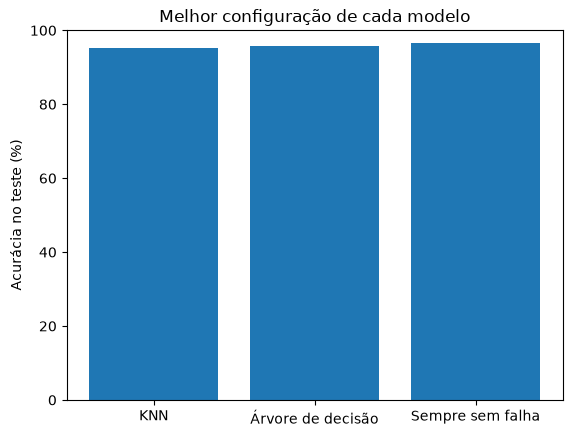

In [30]:
melhor_knn = tabela_knn.loc[tabela_knn["acuracia_teste"].idxmax()]
melhor_arvore = tabela_arvore.loc[tabela_arvore["acuracia_teste"].idxmax()]

if melhor_knn["acuracia_teste"] >= melhor_arvore["acuracia_teste"]:
    nome_vencedor = "KNN"
    parametro_vencedor = f"k={int(melhor_knn['k'])}"
    acuracia_vencedor = melhor_knn["acuracia_teste"]
    treino_vencedor = melhor_knn["acuracia_treino"]
    nome_outro = "Árvore de decisão"
    acuracia_outro = melhor_arvore["acuracia_teste"]
else:
    nome_vencedor = "Árvore de decisão"
    valor_profundidade = melhor_arvore["max_depth"]
    parametro_vencedor = (
        "max_depth=None" if pd.isna(valor_profundidade)
        else f"max_depth={int(valor_profundidade)}"
    )
    acuracia_vencedor = melhor_arvore["acuracia_teste"]
    treino_vencedor = melhor_arvore["acuracia_treino"]
    nome_outro = "KNN"
    acuracia_outro = melhor_knn["acuracia_teste"]

diferenca_treino_teste = treino_vencedor - acuracia_vencedor
acuracia_base = (y_test == 0).mean()
if acuracia_vencedor > acuracia_base:
    print(
        f"A empresa deve avaliar o modelo {nome_vencedor} ({parametro_vencedor}), "
        f"que obteve {acuracia_vencedor * 100:.2f}% de acurácia no teste, "
        f"contra {acuracia_outro * 100:.2f}% do {nome_outro}."
    )
else:
    print(
        f"Entre os modelos avaliados, {nome_vencedor} ({parametro_vencedor}) "
        f"teve a maior acurácia no teste ({acuracia_vencedor * 100:.2f}%, "
        f"contra {acuracia_outro * 100:.2f}% do {nome_outro}), mas não superou "
        f"a referência de prever sempre 'sem falha' ({acuracia_base * 100:.2f}%). "
        "A acurácia sozinha não justifica adotar nenhum dos dois modelos."
    )
if diferenca_treino_teste > 0.03:
    print(
        f"O treino ficou {diferenca_treino_teste * 100:.2f} pontos percentuais "
        "acima do teste, o que sugere possível overfitting."
    )
else:
    print(
        f"A diferença entre treino e teste foi de "
        f"{diferenca_treino_teste * 100:.2f} pontos percentuais, "
        "sem grande sinal de overfitting nesta comparação."
    )
print(
    "Limitação: como as falhas são raras, a acurácia pode esconder falhas "
    "não detectadas. Como melhoria futura, avaliar precision e recall da classe "
    "de falha, especialmente o recall, que mede quantas falhas reais o modelo detectou."
)

# Compara os melhores resultados dos modelos com a referência trivial.
import matplotlib.pyplot as plt

plt.bar(
    ["KNN", "Árvore de decisão", "Sempre sem falha"],
    [
        melhor_knn["acuracia_teste"] * 100,
        melhor_arvore["acuracia_teste"] * 100,
        acuracia_base * 100,
    ],
)
plt.ylabel("Acurácia no teste (%)")
plt.title("Melhor configuração de cada modelo")
plt.ylim(0, 100)
plt.show()